In [41]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.offsetbox import AnchoredText
#mpl.use('agg')

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from ari_exceedance_map_functions import *


In [42]:
dataset = "conus404"
duration = 24

print("working on "+str(duration)+"-hr duration")

### radius around max point
#lat_rad = 2.5
#lon_rad = 3.25
lat_rad = 2.5
lon_rad = 2.75
#lat_rad = 2.5
#lon_rad = 4.


### or try viridis
clevs = [1,2.5,5,10,20,25,37.5,50,62.5,75,87.5,100,125,150,175,200]
#clevs = [1,2.5,5,10,20,25,37.5,50,62.5,75,87.5,100,125,150,200,250]
#clevs = [5,10,25,50,75,100,125,150,200,250,300,400,500]
#clevs = [5,10,25,50,75,100,125,150,200,250,300,350,400,450]
### really extreme version (e.g. Harvey)
#clevs = [5,10,25,50,100,150,200,250,300,400,500,750,1000,1200]
cmap=mpl.colormaps['viridis']
norm = mcolors.BoundaryNorm(clevs, cmap.N, extend='max')
    

working on 24-hr duration


In [43]:
def plot_background(ax,minlon,maxlon,minlat,maxlat,lats=True,lons=True):
    ax.set_extent([minlon,maxlon,minlat,maxlat])
    #ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=1)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=1)

    if (lats==True) & (lons==True):
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=2, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.left_labels = True
        gl.bottom_labels = True
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False
        gl.x_inline = False
        gl.y_inline = False
        gl.xlocator = LongitudeLocator(nbins=7)
        gl.ylocator = LatitudeLocator()
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        gl.rotate_labels = False
        gl.xlabel_style = {'size': 7}
        gl.ylabel_style = {'size': 7}
    elif (lats==True) & (lons==False):
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=2, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.left_labels = True
        gl.bottom_labels = False
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False
        gl.x_inline = False
        gl.y_inline = False
        gl.xlocator = LongitudeLocator(nbins=7)
        gl.ylocator = LatitudeLocator()
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        gl.rotate_labels = False
        gl.xlabel_style = {'size': 7}
        gl.ylabel_style = {'size': 7}        
    elif (lats==False) & (lons==True):
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=2, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.left_labels = False
        gl.bottom_labels = True
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False
        gl.x_inline = False
        gl.y_inline = False
        gl.xlocator = LongitudeLocator(nbins=7)
        gl.ylocator = LatitudeLocator()
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        gl.rotate_labels = False
        gl.xlabel_style = {'size': 7}
        gl.ylabel_style = {'size': 7} 
    
    return ax

In [44]:
### read in precip zarrs
stage4 = xr.open_zarr("/glade/campaign/univ/ucsu0118/gridded_precip_zarr/stage4_24h_prismgrid.zarr/")
#ccpa = xr.open_zarr("/glade/campaign/univ/ucsu0118/gridded_precip_zarr/ccpa_24h_prismgrid.zarr/")
prism = xr.open_zarr("/glade/campaign/univ/ucsu0118/gridded_precip_zarr/prism_24h.zarr/")
#mrms = xr.open_zarr("/glade/campaign/univ/ucsu0118/gridded_precip_zarr/mrms_24h_prismgrid.zarr/")
conus404 = xr.open_zarr("/glade/campaign/univ/ucsu0118/gridded_precip_zarr/conus404_24h_prismgrid.zarr/")


In [45]:
#if duration==24:
#    conus404_exceed = pd.read_csv("conus404/conus404_2002-2022_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit.csv")
conus404_exceed100 = pd.read_csv("conus404/conus404_1981-2022_events_100y"+str(duration).zfill(2)+"h_edit.csv")
conus404_exceed1000 = pd.read_csv("conus404/conus404_1981-2022_events_1000y"+str(duration).zfill(2)+"h_edit.csv")
#else:
#    conus404_exceed100 = pd.read_csv("conus404/conus404_1981-2022_events_100y"+str(duration).zfill(2)+"h_edit_nooverlaps.csv")
#    conus404_exceed1000 = pd.read_csv("conus404/conus404_1981-2022_events_1000y"+str(duration).zfill(2)+"h_edit_nooverlaps.csv")

stage4_exceed100 = pd.read_csv("stage4/stage4_2002-2024_events_100y"+str(duration).zfill(2)+"h_edit.csv")
stage4_exceed1000 = pd.read_csv("stage4/stage4_2002-2024_events_1000y"+str(duration).zfill(2)+"h_edit.csv")

prism_exceed100 = pd.read_csv("prism/prism_1981-2024_events_100y"+str(duration).zfill(2)+"h_edit.csv")
prism_exceed1000 = pd.read_csv("prism/prism_1981-2024_events_1000y"+str(duration).zfill(2)+"h_edit.csv")

event_list = conus404_exceed100.sort_values(by='tp_pct_of_ari').drop_duplicates(['time','event_num'], keep='first')

print("working on "+dataset)
print(str(len(event_list))+" cases")


working on conus404
3007 cases


In [46]:
#event_list[event_list.time=='2008-09-04 12:00:00']
#event_list[event_list.time=='2017-08-28 12:00:00']
#event_list[event_list.time=='2017-08-29 12:00:00']
#event_list[event_list.time=='2021-08-20 12:00:00']
#event_list[event_list.time=='2021-08-22 12:00:00']
event_list[event_list.time=='2022-07-28 12:00:00']

,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
87070,2022-07-28 12:00:00,39.875,-80.45833,130.435,1.452,1.01126,2


working on 2022-07-28 12:00:00, event number 2


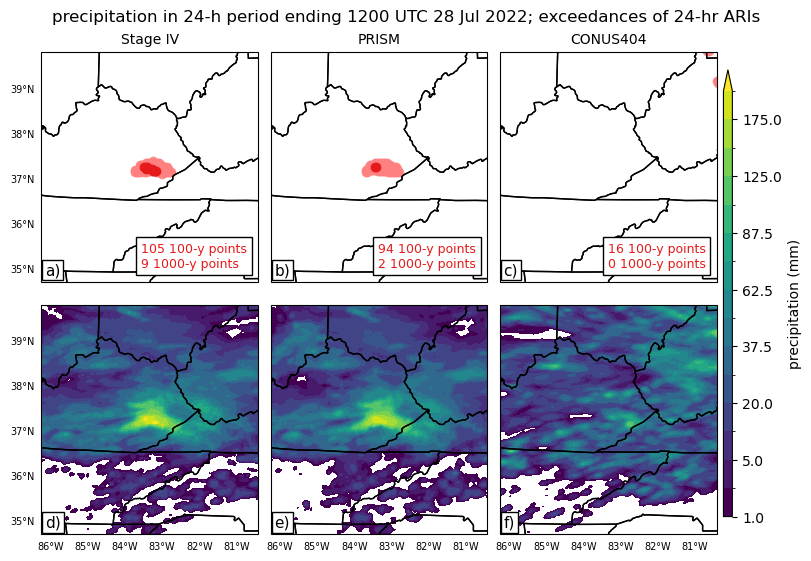

done!


In [47]:
#for i in range(0,len(event_list)):
for i in range(87070,87071):
    this_time = event_list.loc[i].time
    time_pd = pd.to_datetime(this_time)
    this_event = event_list.loc[i].event_num

    print("working on "+this_time+", event number "+str(this_event))   
 
    this_lon = event_list.loc[i].lon
    this_lat = event_list.loc[i].lat
    ### nashville
    #this_lon = -86.78
    #this_lat = 36.16
    ### holyoke
    #this_lon = -102.25
    #this_lat = 40.58
    ### eastern KY
    #this_lon = -83
    #this_lat = 37.25
    
    conus404_points100 = conus404_exceed100[(conus404_exceed100.time == this_time) & (conus404_exceed100.event_num == this_event)]
    conus404_points1000 = conus404_exceed1000[(conus404_exceed1000.time == this_time) & (conus404_exceed1000.event_num == this_event)]
    stage4_points100 = stage4_exceed100[(stage4_exceed100.time == this_time)] # & (stage4_exceed100.lon >= minlon) & (stage4_exceed100.lon <= maxlon) & (stage4_exceed100.lat >= minlat) & (stage4_exceed100.lat <= maxlat)]
    stage4_points1000 = stage4_exceed1000[(stage4_exceed1000.time == this_time)] # & (stage4_exceed1000.lon >= minlon) & (stage4_exceed1000.lon <= maxlon) & (stage4_exceed1000.lat >= minlat) & (stage4_exceed1000.lat <= maxlat)]

    #### make sure to capture larger events that are clustered together
    minlon = conus404_points100.lon.min() - lon_rad
    maxlon = conus404_points100.lon.max() + lon_rad
    minlat = conus404_points100.lat.min() - lat_rad
    maxlat = conus404_points100.lat.max() + lat_rad
    #minlon = stage4_points1000.lon.min() - lon_rad
    #maxlon = stage4_points1000.lon.max() + lon_rad
    #minlat = stage4_points1000.lat.min() - lat_rad
    #maxlat = stage4_points1000.lat.max() + lat_rad
    
    crs = ccrs.LambertConformal(central_longitude=this_lon, central_latitude=this_lat)
  
    fig, axarr = plt.subplots(nrows=2, ncols=3, 
                              #figsize=(8.75,5.5),
                              #figsize=(11, 5.5), 
                              #figsize=(11,5.1),
                              #figsize=(10.5,5.5),
                              figsize=(8.,5.5),
                              constrained_layout=True,
                          subplot_kw={'projection': crs})
    
    axlist = axarr.flatten()
    #for ax in axlist:
    #    plot_background(ax,minlon,maxlon,minlat,maxlat)
    ### only put the lat/lons on some panels
    plot_background(axlist[0],minlon,maxlon,minlat,maxlat,lats=True,lons=False)
    plot_background(axlist[1],minlon,maxlon,minlat,maxlat,lats=False,lons=False)
    plot_background(axlist[2],minlon,maxlon,minlat,maxlat,lats=False,lons=False)    
    plot_background(axlist[3],minlon,maxlon,minlat,maxlat,lats=True,lons=True)
    plot_background(axlist[4],minlon,maxlon,minlat,maxlat,lats=False,lons=True)
    plot_background(axlist[5],minlon,maxlon,minlat,maxlat,lats=False,lons=True)      

######## top 4 panels: points exceeding threshold   
    stage4_points100 = stage4_exceed100[(stage4_exceed100.time == this_time) & (stage4_exceed100.lon >= minlon) & (stage4_exceed100.lon <= maxlon) & (stage4_exceed100.lat >= minlat) & (stage4_exceed100.lat <= maxlat)]
    stage4_points1000 = stage4_exceed1000[(stage4_exceed1000.time == this_time) & (stage4_exceed1000.lon >= minlon) & (stage4_exceed1000.lon <= maxlon) & (stage4_exceed1000.lat >= minlat) & (stage4_exceed1000.lat <= maxlat)]
    cp1 = axlist[0].scatter(stage4_points100.lon,stage4_points100.lat, color=(1, 0.5, 0.5, 0.85),
                          transform=ccrs.PlateCarree())
    cp1b = axlist[0].scatter(stage4_points1000.lon,stage4_points1000.lat, color=(0.9, 0.1, 0.1, 1),
                          transform=ccrs.PlateCarree())
    ### add text saying how many points exceeded
    at1 = AnchoredText(str(len(stage4_points100))+" 100-y points\n"+str(len(stage4_points1000))+" 1000-y points",
                      prop=dict(size=9,color=(0.9, 0.1, 0.1, 1)),
                      frameon=True, loc='lower right')
    axlist[0].add_artist(at1)
    axlist[0].set_title("Stage IV", size=10)

    prism_points100 = prism_exceed100[(prism_exceed100.time == this_time) & (prism_exceed100.lon >= minlon) & (prism_exceed100.lon <= maxlon) & (prism_exceed100.lat >= minlat) & (prism_exceed100.lat <= maxlat)]
    prism_points1000 = prism_exceed1000[(prism_exceed1000.time == this_time) & (prism_exceed1000.lon >= minlon) & (prism_exceed1000.lon <= maxlon) & (prism_exceed1000.lat >= minlat) & (prism_exceed1000.lat <= maxlat)]
    cp2 = axlist[1].scatter(prism_points100.lon,prism_points100.lat, color=(1, 0.5, 0.5, 0.85),
                          transform=ccrs.PlateCarree())
    cp2b = axlist[1].scatter(prism_points1000.lon,prism_points1000.lat, color=(0.9, 0.1, 0.1, 1),
                          transform=ccrs.PlateCarree())
    ### add text saying how many points exceeded
    at2 = AnchoredText(str(len(prism_points100))+" 100-y points\n"+str(len(prism_points1000))+" 1000-y points",
                      prop=dict(size=9,color=(0.9, 0.1, 0.1, 1)),
                      frameon=True, loc='lower right')
    axlist[1].add_artist(at2)
    axlist[1].set_title("PRISM", size=10)
    
    cp4 = axlist[2].scatter(conus404_points100.lon,conus404_points100.lat, color=(1, 0.5, 0.5, 0.85),
                          transform=ccrs.PlateCarree())
    cp4b = axlist[2].scatter(conus404_points1000.lon,conus404_points1000.lat, color=(0.9, 0.1, 0.1, 1),
                          transform=ccrs.PlateCarree())
    ### add text saying how many points exceeded
    at4 = AnchoredText(str(len(conus404_points100))+" 100-y points\n"+str(len(conus404_points1000))+" 1000-y points",
    ## manual edit for Aug 21 cases where there are none associated with this particular event
    #at4 = AnchoredText("0 100-y points\n0 1000-y points",
                      prop=dict(size=9,color=(0.9, 0.1, 0.1, 1)),
                      frameon=True, loc='lower right')
    axlist[2].add_artist(at4)
    axlist[2].set_title("CONUS404", size=10)

######## bottom 4 panels: precip maps
    try:
        if duration > 24:
            stage4_slice = stage4.sel(time=slice(time_pd - pd.Timedelta(hours=duration-1),time_pd),lon=slice(minlon-1,maxlon+1),lat=slice(minlat-1,maxlat+1))
            stage4_this = stage4_slice.tp.sum(dim='time')
        else:
            stage4_this = stage4.sel(time=this_time).tp
        lon2d,lat2d = np.meshgrid(stage4_this.lon,stage4_this.lat)
        cf1 = axlist[3].contourf(lon2d,lat2d,stage4_this,
                             clevs,cmap=cmap, norm=norm, extend='max',
                             transform_first=True,
                             transform=ccrs.PlateCarree())
        #axlist[3].set_title("Stage IV", size=10)
    except:
        axlist[3].set_facecolor(cfeature.COLORS['land'])

    if duration > 24:
        prism_slice = prism.sel(time=slice(time_pd - pd.Timedelta(hours=duration-1),time_pd),lon=slice(minlon-1,maxlon+1),lat=slice(minlat-1,maxlat+1))
        prism_this = prism_slice.tp.sum(dim='time')
    else:
        prism_this = prism.sel(time=this_time).tp
    lon2d,lat2d = np.meshgrid(prism_this.lon,prism_this.lat)
    cf2 = axlist[4].contourf(lon2d,lat2d,prism_this,
                             clevs,cmap=cmap, norm=norm, extend='max',
                             transform_first=True,
                             transform=ccrs.PlateCarree())
    #axlist[4].set_title("PRISM", size=10)

    if duration > 24:
        conus404_slice = conus404.sel(time=slice(time_pd - pd.Timedelta(hours=duration-1),time_pd),lon=slice(minlon-1,maxlon+1),lat=slice(minlat-1,maxlat+1))
        conus404_this = conus404_slice.tp.sum(dim='time')
    else:
        conus404_this = conus404.sel(time=this_time).tp
    lon2d,lat2d = np.meshgrid(conus404_this.lon,conus404_this.lat)
    cf4 = axlist[5].contourf(lon2d,lat2d,conus404_this,
                             clevs,cmap=cmap, norm=norm, extend='max',
                             transform_first=True,
                             transform=ccrs.PlateCarree())
    #axlist[5].set_title("CONUS404", size=10)

    cb = plt.colorbar(cf4, ax=axlist, orientation='vertical', 
                 aspect=50, shrink=0.9, pad=0.01)
    cb.set_label("precipitation (mm)", size=10)

    ### add panel labels
    panel_letter = 'a'
    for counter in range(0,6):
        label = chr(ord(panel_letter) + counter)
        axlist[counter].annotate(
            label+")",
            xy=(0, 0), xycoords='axes fraction',
            xytext=(+0.25, +1.25), textcoords='offset fontsize',
            fontsize=11, verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='black', pad=2.0))

    plt.suptitle("precipitation in "+str(duration)+"-h period ending "+time_pd.strftime("%H%M UTC %-d %b %Y")+"; exceedances of "+str(duration)+"-hr ARIs", size=12)

    outfile = "conus404_compare_"+str(duration)+"h_"+time_pd.strftime("%Y%m%d%H")+"_pub.pdf"
    fig.savefig(outfile, dpi=300)
            
    plt.show()

    plt.close('all')

print("done!")
